Загрузка датасета

Датасет содержит сетевой трафик, размеченный по 14 классам 
(1 benign + 13 типов атак). 

Исходная структура включала 15 директорий с атаками, 
однако три варианта DDoS-атак (ICMP flood, RAW socket, UDP flood) 
были объединены в единый класс "DDoS", поскольку:
• Цель работы — обнаружение факта атаки, а не её конкретной техники
• Признаки этих подтипов частично перекрываются
• Объединение улучшает баланс классов и стабильность модели

При необходимости детальной классификации техник DDoS 
предложенный пайплайна может быть легко адаптирован 
путём разделения класса на три подкласса.

In [1]:
# Шаг 1: Загрузка датасета LSNM2024
import pandas as pd
import glob
import os
from pathlib import Path


def load_dataset(root_dir="LSNM2024/Dataset"):
    """Найти все CSV файлы в датасете"""
    benign_files = glob.glob(os.path.join(root_dir, "Benign", "*.csv"))
    malicious_files = glob.glob(os.path.join(root_dir, "Malicious", "*", "*.csv"))
    
    all_files = benign_files + malicious_files
    print(f"Найдено файлов: {len(all_files)} (Benign: {len(benign_files)}, Malicious: {len(malicious_files)})")
    
    return all_files


def extract_attack_class(filepath):
    """Определить класс атаки по имени папки"""
    
    # Benign — отдельная папка
    if "Benign" in filepath:
        return "Benign"
    
    # Malicious — берём имя подпапки
    if "Malicious" in filepath:
        parts = Path(filepath).parts
        try:
            idx = parts.index("Malicious")
            folder = parts[idx + 1].lower()
        except (IndexError, ValueError):
            return "Unknown"
        
        # классы атак
        mapping = {
            'arp-spoof': 'ARP-spoof',
            'arp spoof': 'ARP-spoof',
            'ddos icmp': 'DDoS',
            'ddos raw': 'DDoS',
            'ddos-udp': 'DDoS',
            'dos': 'DoS',
            'exploiting ftp': 'FTP-Attack',
            'ftp brute force': 'FTP-Brute-Force',
            'fuzzing': 'Fuzzing',
            'icmp flood': 'ICMP-Flood',
            'port scanning': 'Port-Scanning',
            'remote code execution': 'RCE',
            'rce': 'RCE',
            'sql injection': 'SQL-Injection',
            'sql-injection': 'SQL-Injection',
            'ssh brute force': 'SSH-Brute-Force',
            'syn flood': 'SYN-Flood',
            'xss': 'XSS',
        }
        
        return mapping.get(folder, f"Unknown-{folder}")
    
    return "Unknown"


def load(all_files):
    """Загрузить все CSV файлы в один DataFrame"""
    
    if not all_files:
        raise ValueError("Нет файлов для загрузки")
    
    dfs = []
    for file in all_files:
        # Пропускаем не-CVS файлы
        if not file.lower().endswith('.csv'):
            continue
        
        try:
            df = pd.read_csv(file, low_memory=False)
            df["attack_class"] = extract_attack_class(file)
            dfs.append(df)
        except Exception as e:
            print(f" Пропущен файл {file}: {e}")
            continue
    
    if not dfs:
        raise ValueError("Не удалось загрузить ни один файл")
    
    data = pd.concat(dfs, axis=0, ignore_index=True)
    print(f"Загружено: {data.shape[0]:,} строк, {data.shape[1]} столбцов")
    
    return data

all_files = load_dataset()
data_full = load(all_files)

print(f"\nРазмер датасета: {data_full.shape}")
print(f"\nКлассы атак:\n{data_full['attack_class'].value_counts()}")

Найдено файлов: 21 (Benign: 1, Malicious: 20)
Загружено: 4,543,916 строк, 63 столбцов

Размер датасета: (4543916, 63)

Классы атак:
attack_class
Benign             1259470
DDoS                844685
DoS                 369288
SQL-Injection       287725
RCE                 278873
ICMP-Flood          240082
XSS                 217591
FTP-Attack          207803
SYN-Flood           199949
Port-Scanning       162319
SSH-Brute-Force     139762
FTP-Brute-Force     121916
Fuzzing             117558
ARP-spoof            96895
Name: count, dtype: int64


Сохранение объединенного датасета

In [3]:
import os  
directory = "processed"  
if not os.path.exists(directory):  
    os.makedirs(directory)  
    print("Directory created")  
else:  
    print("Directory already exists") 

# Сохранение загруженного датасета
data_full.to_csv("processed/data_full.csv", index=False)
print(" Датасет сохранён: processed/data_full.csv")

# Загрузка:
# data_full = pd.read_csv("LSNM2024/processed/data_full.csv")

Directory already exists
 Датасет сохранён: processed/data_full.csv


In [1]:
# Шаг 2: Первичный анализ датасета LSNM2024
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import base64
from io import BytesIO
import os

# Настройка визуализаций
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

sns.set_context('notebook', font_scale=1.1)

In [2]:
# Загружаем сохранённый датасет
data_full = pd.read_csv("processed/data_full.csv", low_memory=False)
print(f"Загружено: {data_full.shape[0]:,} строк × {data_full.shape[1]} признаков")

Загружено: 4,543,916 строк × 63 признаков


Общая информация о датасете

In [ ]:
# 1. Общая информация
print(f"\n Размер датасета: {data_full.shape}")
print(f" Типы данных:\n{data_full.dtypes.value_counts()}")
print(f" Потребление памяти: {data_full.memory_usage(deep=True).sum()/1024**2:.2f} MB")

# 2. Целевая переменная
print(f"\n Классы атак ({data_full['attack_class'].nunique()} уникальных):")
print(data_full['attack_class'].value_counts())

# 3. Пропуски
missing = data_full.isna().sum()
if missing.any():
    print(f"\n Пропуски в столбцах:")
    print(missing[missing > 0])
else:
    print(f"\n Пропущенных значений нет")

# 4. Пример данных
print(f"\n Первые 5 строк:")
print(data_full.head())


 Размер датасета: (4543916, 63)
 Типы данных:
object     45
float64    15
int64       3
Name: count, dtype: int64
 Потребление памяти: 9845.49 MB

 Классы атак (14 уникальных):
attack_class
Benign             1259470
DDoS                844685
DoS                 369288
SQL-Injection       287725
RCE                 278873
ICMP-Flood          240082
XSS                 217591
FTP-Attack          207803
SYN-Flood           199949
Port-Scanning       162319
SSH-Brute-Force     139762
FTP-Brute-Force     121916
Fuzzing             117558
ARP-spoof            96895
Name: count, dtype: int64

 Пропуски в столбцах:
Info                              17
frame number                  369288
IP Source                      99669
IP Destination                 99669
IP Length                      99669
IP TTL                         99669
IP Flags                       99669
IP Fragment Offset             99669
IP Protocol                    99669
IP Version                     99318
IP DSCP Fiel

Графики по EDA

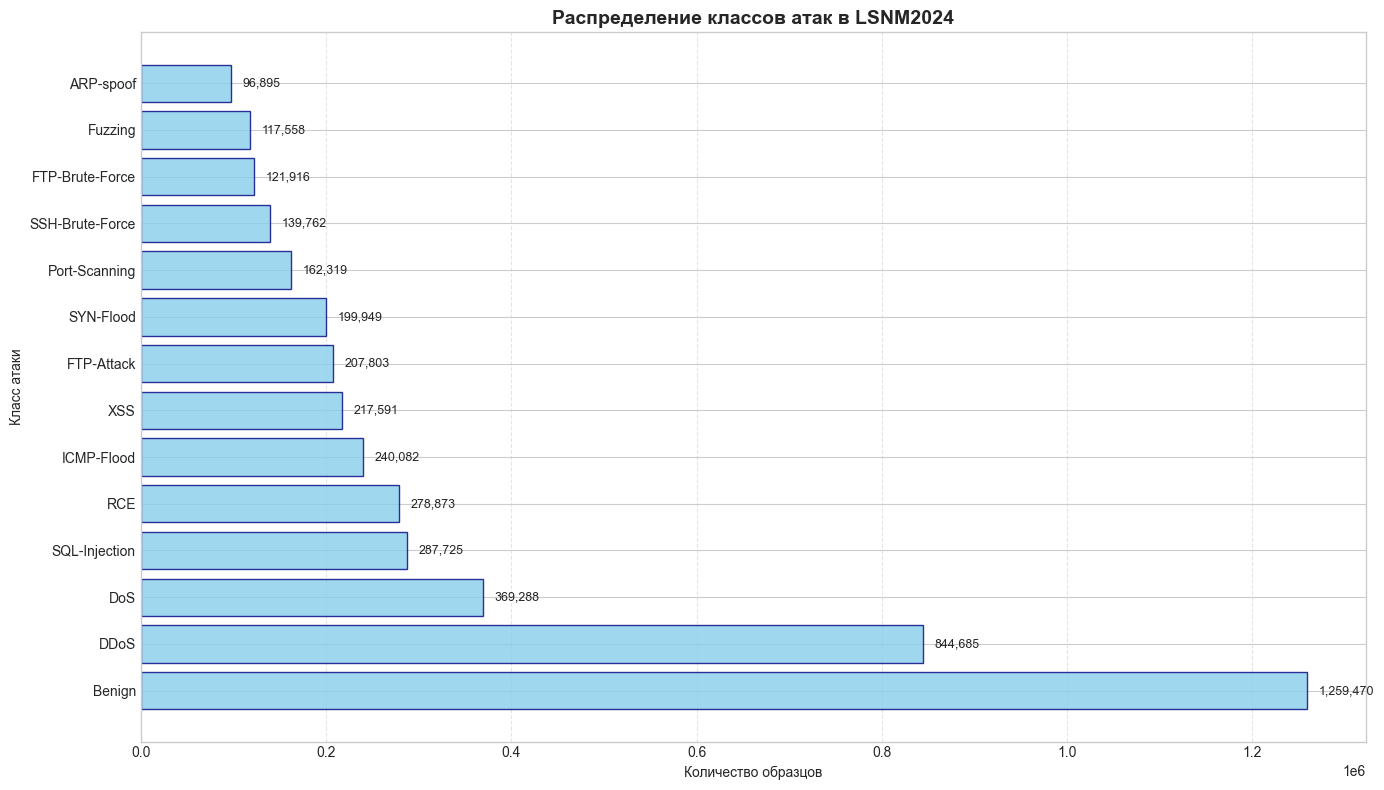

График распределения классов сохранён в base64


In [8]:
def plot_to_base64(figsize=(12, 6)):
    """Сохранить текущий matplotlib график в base64-строку"""
    buf = BytesIO()
    plt.savefig(buf, format='png', bbox_inches='tight', dpi=100)
    buf.seek(0)
    img_base64 = base64.b64encode(buf.read()).decode('utf-8')
    plt.close()  # освободить память
    return img_base64


# График распределения классов атак
plt.figure(figsize=(14, 8))
counts = data_full['attack_class'].value_counts()
bars = plt.barh(counts.index, counts.values, color='skyblue', edgecolor='navy', alpha=0.8)

plt.title('Распределение классов атак в LSNM2024', fontsize=14, fontweight='bold')
plt.xlabel('Количество образцов')
plt.ylabel('Класс атаки')
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Подписи значений
for bar, val in zip(bars, counts.values):
    plt.text(val + max(counts.values)*0.01, bar.get_y() + bar.get_height()/2, 
             f'{val:,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()
attack_dist_plot = plot_to_base64()  # Сохраняем график в base64
print("График распределения классов сохранён в base64")

C:\Users\аля\AppData\Local\Temp\ipykernel_16532\638032472.py:58: UserWarning: Glyph 128208 (\N{TRIANGULAR RULER}) missing from font(s) Arial.
  plt.tight_layout(rect=[0, 0, 1, 0.96])
C:\Users\аля\AppData\Local\Temp\ipykernel_16532\638032472.py:59: UserWarning: Glyph 128208 (\N{TRIANGULAR RULER}) missing from font(s) Arial.
  plt.savefig('processed/eda_dashboard.png', dpi=300, bbox_inches='tight')
d:\anaconda\anaconda3\envs\notebook\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128208 (\N{TRIANGULAR RULER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


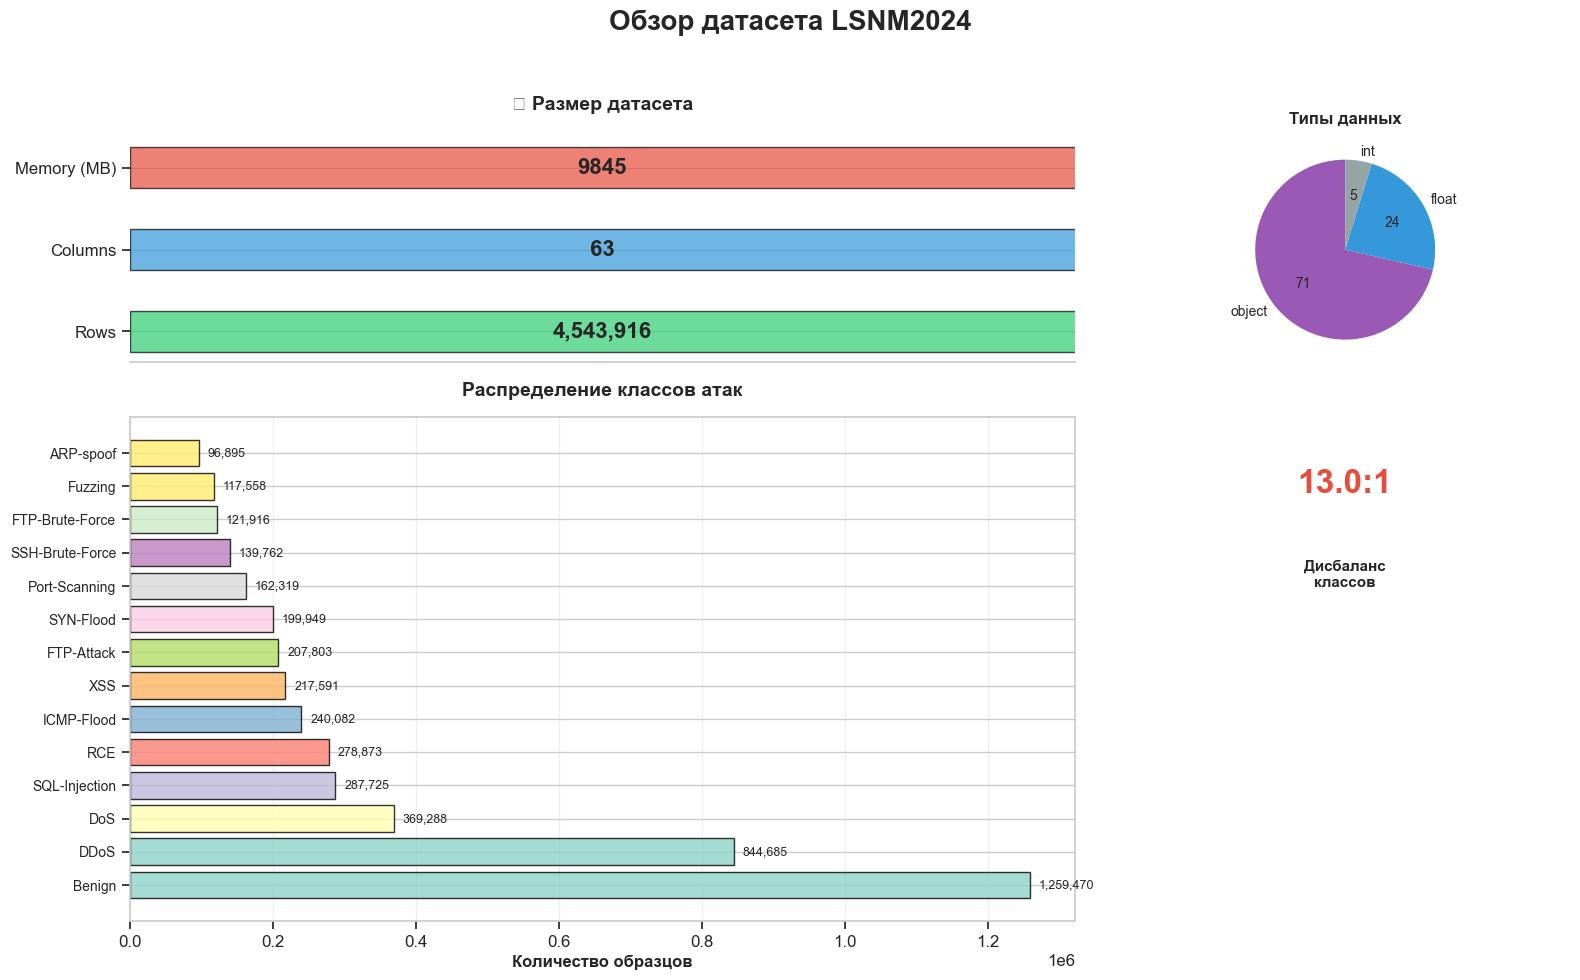

Dashboard сохранён: processed/eda_dashboard.png


In [11]:
fig = plt.figure(figsize=(16, 10))
fig.suptitle('Обзор датасета LSNM2024', fontsize=20, fontweight='bold', y=0.98)

# Блок 1: Основные метрики
ax1 = plt.subplot2grid((3, 3), (0, 0), colspan=2)
metrics = ['Rows', 'Columns', 'Memory (MB)']
values = [f'{data_full.shape[0]:,}', data_full.shape[1], f'{data_full.memory_usage(deep=True).sum()/1024**2:.0f}']
colors = ['#2ecc71', '#3498db', '#e74c3c']

bars = ax1.barh(metrics, [len(values)]*3, color=colors, alpha=0.7, edgecolor='black', height=0.5)
ax1.set_xlim(0, 1)
ax1.set_xticks([])
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_visible(False)

# Добавляем значения
for i, (bar, val) in enumerate(zip(bars, values)):
    ax1.text(0.5, i, str(val), ha='center', va='center', fontsize=16, fontweight='bold')

ax1.set_title('📐 Размер датасета', fontsize=14, fontweight='bold', pad=20)

# Блок 2: Типы данных
ax2 = plt.subplot2grid((3, 3), (0, 2))
dtypes_counts = data_full.dtypes.value_counts()
colors_pie = ['#9b59b6', '#3498db', '#95a5a6']
ax2.pie(dtypes_counts.values, labels=[str(t).replace('64', '') for t in dtypes_counts.index], 
        autopct='%1.0f', colors=colors_pie, startangle=90, textprops={'fontsize': 10})
ax2.set_title('Типы данных', fontsize=12, fontweight='bold', pad=10)

# Блок 3: Классы атак
ax3 = plt.subplot2grid((3, 3), (1, 0), colspan=2, rowspan=2)
class_counts = data_full['attack_class'].value_counts()
colors_bar = plt.cm.Set3(np.linspace(0, 1, len(class_counts)))

bars = ax3.barh(range(len(class_counts)), class_counts.values, color=colors_bar, edgecolor='black', alpha=0.8)
ax3.set_yticks(range(len(class_counts)))
ax3.set_yticklabels(class_counts.index, fontsize=10)
ax3.set_xlabel('Количество образцов', fontsize=12, fontweight='bold')
ax3.set_title('Распределение классов атак', fontsize=14, fontweight='bold', pad=15)
ax3.grid(axis='x', alpha=0.3)

# Добавляем значения на столбцы
for i, (bar, val) in enumerate(zip(bars, class_counts.values)):
    ax3.text(val + max(class_counts.values)*0.01, i, f'{val:,}', va='center', fontsize=9)

# Блок 4: Дисбаланс
ax4 = plt.subplot2grid((3, 3), (1, 2))
imbalance_ratio = class_counts.max() / class_counts.min()
ax4.text(0.5, 0.7, f'{imbalance_ratio:.1f}:1', ha='center', va='center', 
         fontsize=24, fontweight='bold', color='#e74c3c')
ax4.text(0.5, 0.3, 'Дисбаланс\nклассов', ha='center', va='center', 
         fontsize=11, fontweight='bold')
ax4.set_xlim(0, 1)
ax4.set_ylim(0, 1)
ax4.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('processed/eda_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()
print("Dashboard сохранён: processed/eda_dashboard.png")

C:\Users\аля\AppData\Local\Temp\ipykernel_16532\2406655984.py:62: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  proto_missing = data_full.groupby('Protocol').apply(lambda x: x.isna().sum().sum() / x.size * 100)


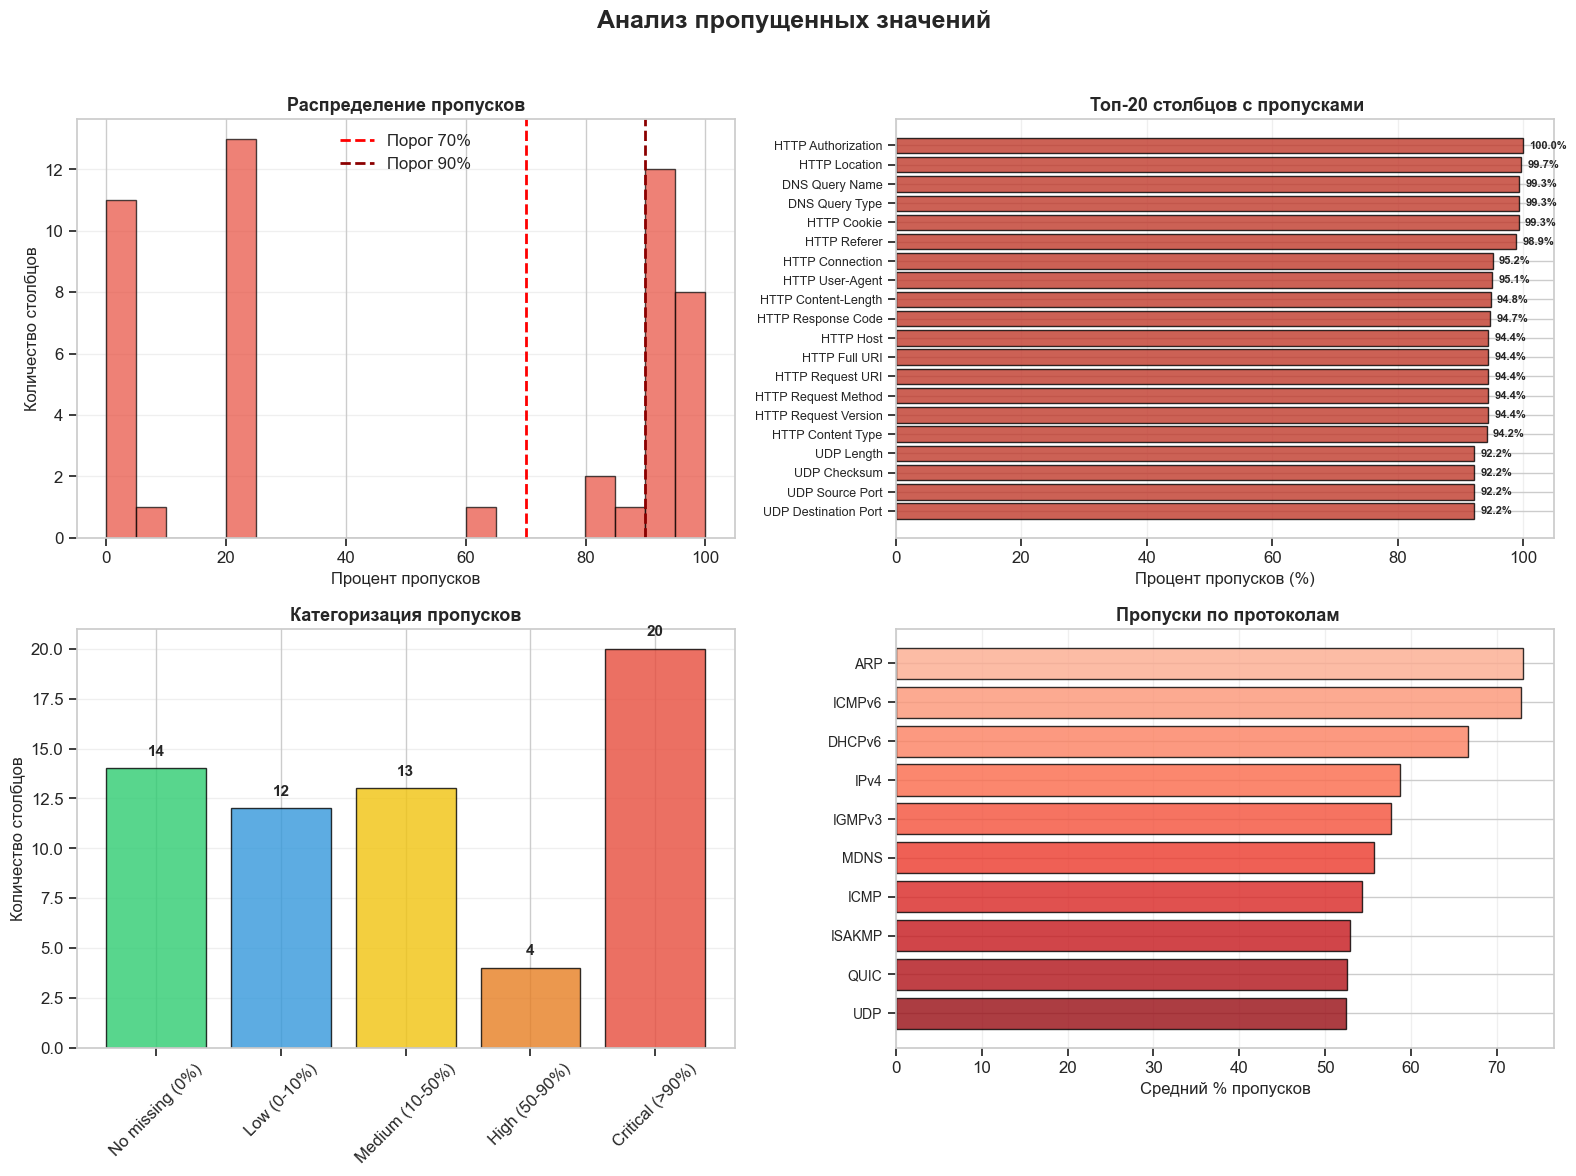

 Анализ пропусков сохранён: processed/missing_values_analysis.png


In [17]:
#Пропущенные значения
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(' Анализ пропущенных значений', fontsize=18, fontweight='bold', y=0.98)

missing = data_full.isna().sum()
missing_pct = (missing / len(data_full) * 100).sort_values(ascending=False)
missing_df = pd.DataFrame({'Column': missing_pct.index, 'Missing_Pct': missing_pct.values})

# 2.1: Распределение % пропусков
ax1 = axes[0, 0]
high_missing = missing_pct[missing_pct > 0]
ax1.hist(high_missing, bins=20, color='#e74c3c', edgecolor='black', alpha=0.7)
ax1.axvline(x=70, color='red', linestyle='--', linewidth=2, label='Порог 70%')
ax1.axvline(x=90, color='darkred', linestyle='--', linewidth=2, label='Порог 90%')
ax1.set_xlabel('Процент пропусков', fontsize=12)
ax1.set_ylabel('Количество столбцов', fontsize=12)
ax1.set_title('Распределение пропусков', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# 2.2: Топ-20 столбцов с наибольшими пропусками
ax2 = axes[0, 1]
top_20_missing = missing_pct.head(20)
colors = ['#c0392b' if x > 90 else '#e67e22' if x > 70 else '#f39c12' for x in top_20_missing]
bars = ax2.barh(range(len(top_20_missing)), top_20_missing.values, color=colors, edgecolor='black', alpha=0.8)
ax2.set_yticks(range(len(top_20_missing)))
ax2.set_yticklabels([col[:25] + '...' if len(col) > 25 else col for col in top_20_missing.index], fontsize=9)
ax2.set_xlabel('Процент пропусков (%)', fontsize=12)
ax2.set_title(' Топ-20 столбцов с пропусками', fontsize=13, fontweight='bold')
ax2.invert_yaxis()
ax2.grid(axis='x', alpha=0.3)

# Добавляем значения
for i, (bar, val) in enumerate(zip(bars, top_20_missing.values)):
    ax2.text(val + 1, i, f'{val:.1f}%', va='center', fontsize=8, fontweight='bold')

# 2.3: Категоризация столбцов
ax3 = axes[1, 0]
categories = {
    'No missing (0%)': (missing_pct == 0).sum(),
    'Low (0-10%)': ((missing_pct > 0) & (missing_pct <= 10)).sum(),
    'Medium (10-50%)': ((missing_pct > 10) & (missing_pct <= 50)).sum(),
    'High (50-90%)': ((missing_pct > 50) & (missing_pct < 90)).sum(),
    'Critical (>90%)': (missing_pct >= 90).sum()
}
colors_cat = ['#2ecc71', '#3498db', '#f1c40f', '#e67e22', '#e74c3c']
bars = ax3.bar(categories.keys(), categories.values(), color=colors_cat, edgecolor='black', alpha=0.8)
ax3.set_ylabel('Количество столбцов', fontsize=12)
ax3.set_title('Категоризация пропусков', fontsize=13, fontweight='bold')
ax3.tick_params(axis='x', rotation=45)
ax3.grid(axis='y', alpha=0.3)

# Добавляем значения
for bar, val in zip(bars, categories.values()):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, str(val), 
             ha='center', va='bottom', fontsize=11, fontweight='bold')
    

# 2.4: Пропуски по протоколам (если есть Protocol)
ax4 = axes[1, 1]
if 'Protocol' in data_full.columns:
    proto_missing = data_full.groupby('Protocol').apply(lambda x: x.isna().sum().sum() / x.size * 100)
    proto_missing = proto_missing.sort_values(ascending=False).head(10)
    colors_proto = plt.cm.Reds(np.linspace(0.3, 0.9, len(proto_missing)))
    bars = ax4.barh(range(len(proto_missing)), proto_missing.values, color=colors_proto, edgecolor='black', alpha=0.8)
    ax4.set_yticks(range(len(proto_missing)))
    ax4.set_yticklabels(proto_missing.index, fontsize=10)
    ax4.set_xlabel('Средний % пропусков', fontsize=12)
    ax4.set_title(' Пропуски по протоколам', fontsize=13, fontweight='bold')
    ax4.invert_yaxis()
    ax4.grid(axis='x', alpha=0.3)
else:
    ax4.text(0.5, 0.5, 'Столбец Protocol\nне найден', ha='center', va='center', 
             fontsize=14, transform=ax4.transAxes)
    ax4.set_xlim(0, 1)
    ax4.set_ylim(0, 1)
    ax4.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('processed/missing_values_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Анализ пропусков сохранён: processed/missing_values_analysis.png")

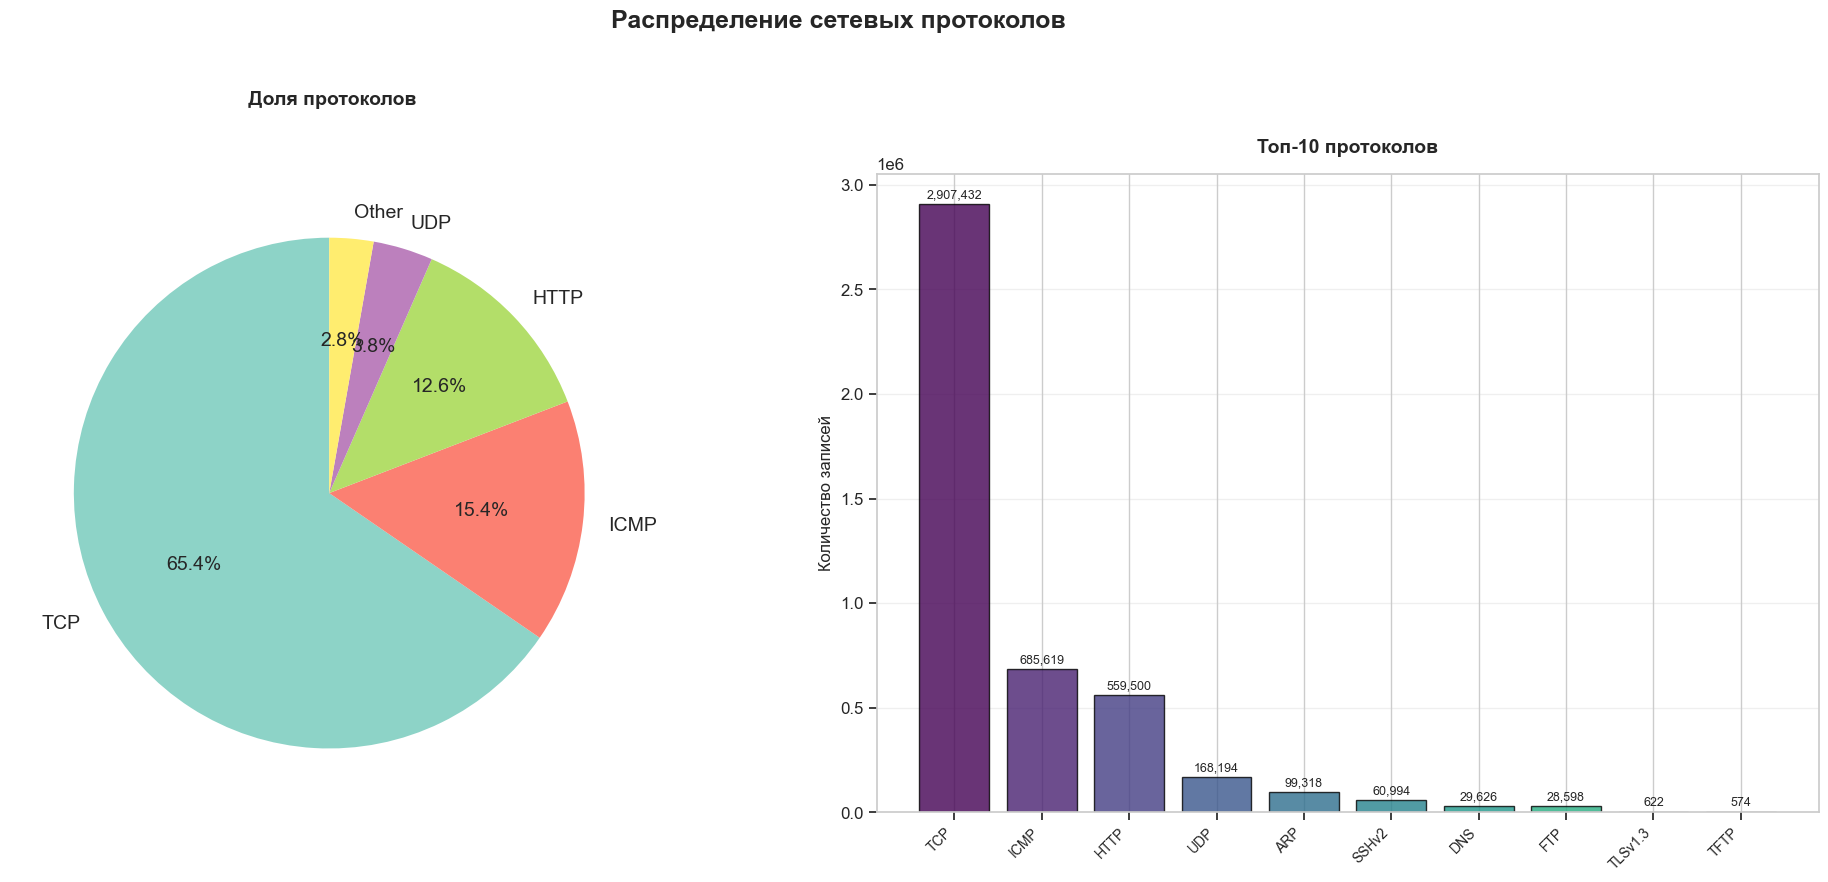

 Распределение протоколов сохранено: processed/protocol_distribution.png


In [35]:
if 'Protocol' in data_full.columns:
    fig, axes = plt.subplots(1, 2, figsize=(20,9))
    fig.suptitle('Распределение сетевых протоколов', fontsize=18, fontweight='bold', y=0.98)
    
    proto_counts = data_full['Protocol'].value_counts()
    
    # 3.1: Pie chart (топ-4 + Other)
    ax1 = axes[0]
    if len(proto_counts) > 4:
        top_4 = proto_counts.head(4)
        other = proto_counts[5:].sum()
        proto_plot = pd.Series([*top_4.values, other], index=[*top_4.index, 'Other'])
    else:
        proto_plot = proto_counts
    
    colors_pie = plt.cm.Set3(np.linspace(0, 1, len(proto_plot)))
    wedges, texts, autotexts = ax1.pie(proto_plot.values, labels=proto_plot.index, 
                                        autopct='%1.1f%%', colors=colors_pie, 
                                        startangle=90, textprops={'fontsize': 14})
    ax1.set_title(' Доля протоколов', fontsize=14, fontweight='bold', pad=50)
    
# 3.2: Bar chart
    ax2 = axes[1]
    top_10 = proto_counts.head(10)
    colors_bar = plt.cm.viridis(np.linspace(0, 0.8, len(top_10)))
    bars = ax2.bar(range(len(top_10)), top_10.values, color=colors_bar, edgecolor='black', alpha=0.8)
    ax2.set_xticks(range(len(top_10)))
    ax2.set_xticklabels(top_10.index, rotation=45, ha='right', fontsize=10)
    ax2.set_ylabel('Количество записей', fontsize=12)
    ax2.set_title('Топ-10 протоколов', fontsize=14, fontweight='bold', pad=15)
    ax2.grid(axis='y', alpha=0.3)
    
    # Добавляем значения
    for bar, val in zip(bars, top_10.values):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(top_10.values)*0.01, 
                 f'{val:,}', ha='center', fontsize=9)
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig('processed/protocol_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(" Распределение протоколов сохранено: processed/protocol_distribution.png")


C:\Users\аля\AppData\Local\Temp\ipykernel_16532\2393328101.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(data_to_plot, labels=[cls[:15] for cls in top_5_classes], patch_artist=True,


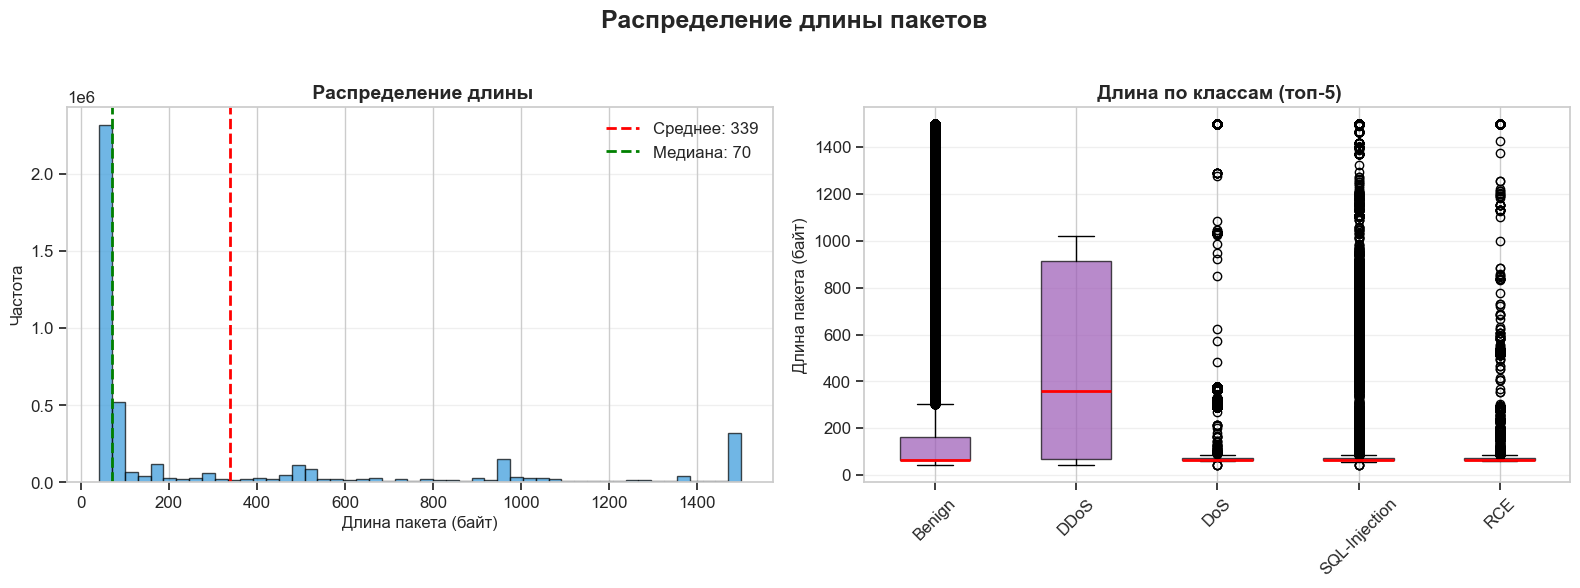

 Распределение длины пакетов сохранено: processed/length_distribution.png


In [37]:
if 'Length' in data_full.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(' Распределение длины пакетов', fontsize=18, fontweight='bold', y=0.98)
    
    # 4.1: Гистограмма
    ax1 = axes[0]
    lengths = data_full['Length'].clip(0, 1500)  # Обрезаем выбросы
    ax1.hist(lengths, bins=50, color='#3498db', edgecolor='black', alpha=0.7)
    ax1.axvline(lengths.mean(), color='red', linestyle='--', linewidth=2, label=f'Среднее: {lengths.mean():.0f}')
    ax1.axvline(lengths.median(), color='green', linestyle='--', linewidth=2, label=f'Медиана: {lengths.median():.0f}')
    ax1.set_xlabel('Длина пакета (байт)', fontsize=12)
    ax1.set_ylabel('Частота', fontsize=12)
    ax1.set_title(' Распределение длины', fontsize=14, fontweight='bold')
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)

 # 4.2: Box plot по классам атак (топ-5)
    ax2 = axes[1]
    top_5_classes = data_full['attack_class'].value_counts().head(5).index
    data_top5 = data_full[data_full['attack_class'].isin(top_5_classes)]
    data_to_plot = [data_top5[data_top5['attack_class']==cls]['Length'].clip(0, 1500).dropna() for cls in top_5_classes]
    
    bp = ax2.boxplot(data_to_plot, labels=[cls[:15] for cls in top_5_classes], patch_artist=True,
                     boxprops=dict(facecolor='#9b59b6', alpha=0.7), medianprops=dict(color='red', linewidth=2))
    ax2.set_ylabel('Длина пакета (байт)', fontsize=12)
    ax2.set_title(' Длина по классам (топ-5)', fontsize=14, fontweight='bold')
    ax2.tick_params(axis='x', rotation=45)
    ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig('processed/length_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(" Распределение длины пакетов сохранено: processed/length_distribution.png")

In [3]:
data_full.columns

Index(['No.', 'Time', 'Source', 'Destination', 'Protocol', 'Length', 'Info',
       'frame number', 'frame length', 'Frame Time', 'Frame Time (Epoch)',
       'Frame Protocols', 'Ethernet Source', 'Ethernet Destination',
       'Ethernet Type', 'IP Source', 'IP Destination', 'IP Length', 'IP TTL',
       'IP Flags', 'IP Fragment Offset', 'IP Protocol', 'IP Version',
       'IP DSCP Field', 'IP Checksum', 'TCP Source Port',
       'TCP Destination Port', 'TCP Length', 'TCP Sequence Number',
       'TCP Acknowledgment Number', 'TCP Flags', 'TCP SYN Flag',
       'TCP ACK Flag', 'TCP FIN Flag', 'TCP RST Flag', 'TCP Window Size',
       'TCP Checksum', 'TCP Stream', 'UDP Source Port', 'UDP Destination Port',
       'UDP Length', 'UDP Checksum', 'ICMP Type', 'ICMP Checksum',
       'HTTP Request Method', 'HTTP Request URI', 'HTTP Request Version',
       'HTTP Full URI', 'HTTP Response Code', 'HTTP User-Agent',
       'HTTP Content-Length', 'HTTP Content Type', 'HTTP Cookie', 'HTTP Host',
 

Разделение признаков на числовые, категориальные и временные

In [4]:
import pandas as pd
import numpy as np
import json
import os

#Классификация признаков
def classify_features(data):
    """
    Классифицирует признаки на числовые, категориальные и временные
    """
    numeric = []
    categorical = []
    temporal = []
    
    temporal_keywords = ['time', 'date', 'timestamp', 'epoch', 'deltatime']
    
    for col in data.columns:
        col_lower = col.lower()
        
        if data[col].dtype in ['int64', 'float64']:
            if any(keyword in col_lower for keyword in temporal_keywords):
                temporal.append(col)
            else:
                numeric.append(col)
        elif data[col].dtype == 'object':
            if any(keyword in col_lower for keyword in temporal_keywords):
                temporal.append(col)
            else:
                categorical.append(col)
        elif data[col].dtype == 'bool':
            categorical.append(col)
    
    return numeric, categorical, temporal

numeric_features, categorical_features, temporal_features = classify_features(data_full)

results = {
    'numeric_features': numeric_features,
    'categorical_features': categorical_features,
    'temporal_features': temporal_features,
    'n_numeric': len(numeric_features),
    'n_categorical': len(categorical_features),
    'n_temporal': len(temporal_features)
}

print(f'числовые признаки: {len(numeric_features)}')
print(f'категориальные признаки: {len(categorical_features)}')
print(f'временные признаки: {len(temporal_features)}')

числовые признаки: 15
категориальные признаки: 44
временные признаки: 4


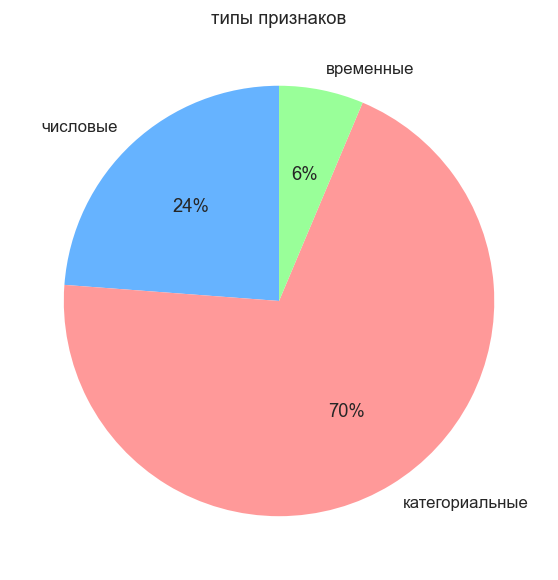

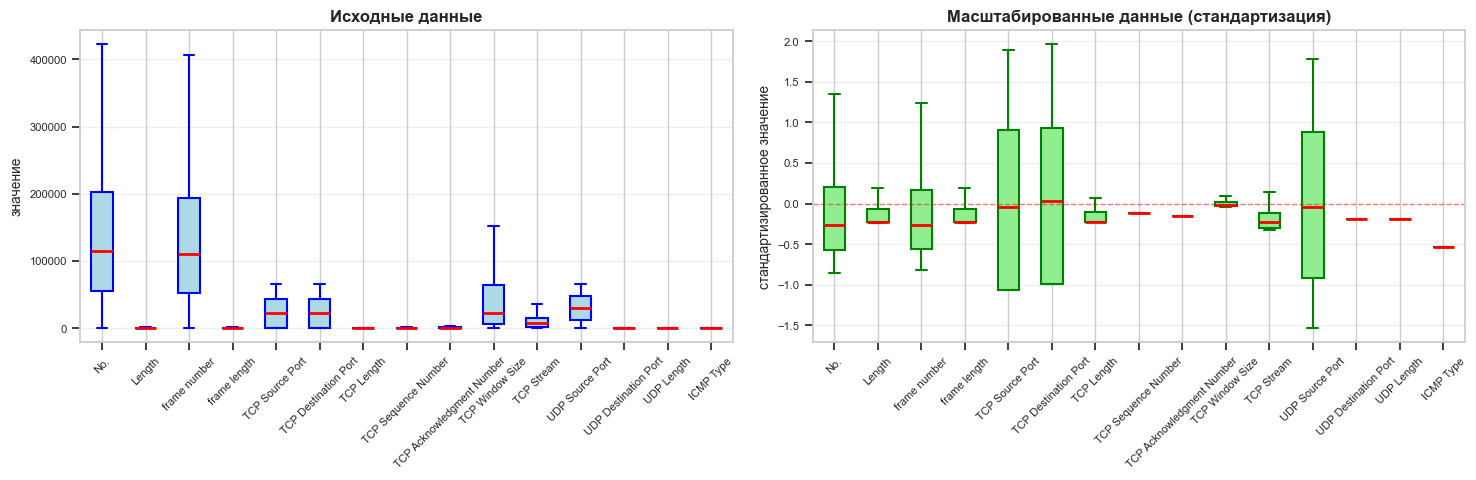

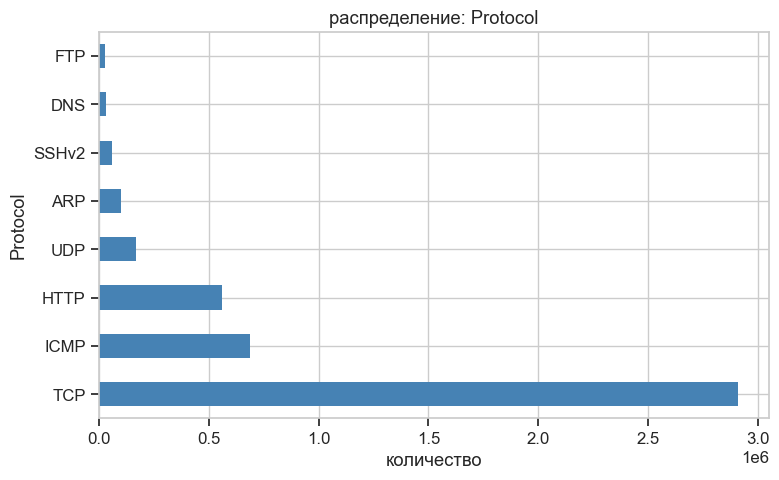

графики: ['processed/feature_types_pie.png', 'processed/numeric_summary.png', 'processed/categorical_sample.png']
статистика подготовлена для 2 групп признаков


In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

os.makedirs('processed', exist_ok=True)

visualizations = {}
summary_tables = {}

fig, ax = plt.subplots(figsize=(6, 6))
labels = ['числовые', 'категориальные', 'временные']
sizes = [results['n_numeric'], results['n_categorical'], results['n_temporal']]
colors = ['#66b3ff', '#ff9999', '#99ff99']
ax.pie(sizes, labels=labels, colors=colors, autopct='%1.0f%%', startangle=90)
ax.set_title('типы признаков')
plt.tight_layout()
plt.savefig('processed/feature_types_pie.png', dpi=150, bbox_inches='tight')
plt.show()
visualizations['feature_types'] = 'processed/feature_types_pie.png'

numeric_data = data_full[numeric_features].select_dtypes(include=[np.number])
if not numeric_data.empty:
    # Нормализация данных для лучшей визуализации
    from sklearn.preprocessing import StandardScaler
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Оригинальные данные
    bp1 = numeric_data.boxplot(ax=axes[0], rot=45, fontsize=8, showfliers=False, 
                               patch_artist=True,  # добавляет заливку
                               boxprops=dict(facecolor='lightblue', color='blue', linewidth=1.5),
                               whiskerprops=dict(color='blue', linewidth=1.5),
                               capprops=dict(color='blue', linewidth=1.5),
                               medianprops=dict(color='red', linewidth=2),
                               flierprops=dict(marker='o', markerfacecolor='gray', markersize=3))
    axes[0].set_title('Исходные данные', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('значение', fontsize=10)
    axes[0].grid(True, alpha=0.3, axis='y')
    
    # Масштабированные данные
    scaler = StandardScaler()
    scaled_data = pd.DataFrame(
        scaler.fit_transform(numeric_data),
        columns=numeric_data.columns
    )
    bp2 = scaled_data.boxplot(ax=axes[1], rot=45, fontsize=8, showfliers=False,
                              patch_artist=True,
                              boxprops=dict(facecolor='lightgreen', color='green', linewidth=1.5),
                              whiskerprops=dict(color='green', linewidth=1.5),
                              capprops=dict(color='green', linewidth=1.5),
                              medianprops=dict(color='red', linewidth=2),
                              flierprops=dict(marker='o', markerfacecolor='gray', markersize=3))
    axes[1].set_title('Масштабированные данные (стандартизация)', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('стандартизированное значение', fontsize=10)
    axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.5, linewidth=1)
    axes[1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig('processed/numeric_summary.png', dpi=150, bbox_inches='tight')
    plt.show()
    visualizations['numeric'] = 'processed/numeric_summary.png'
    
    summary_tables['numeric_stats'] = numeric_data.describe().T[['mean', 'std']].round(2).to_dict(orient='index')

if categorical_features:
    cat_with_low_card = [c for c in categorical_features if data_full[c].nunique() <= 15]
    if cat_with_low_card:
        col = 'Protocol' if 'Protocol' in categorical_features else ('attack_class' if 'attack_class' in categorical_features else cat_with_low_card[0])
        fig, ax = plt.subplots(figsize=(8, 5))
        data_full[col].value_counts().head(8).plot(kind='barh', ax=ax, color='steelblue')
        ax.set_title(f'распределение: {col}')
        ax.set_xlabel('количество')
        plt.tight_layout()
        plt.savefig('processed/categorical_sample.png', dpi=150, bbox_inches='tight')
        plt.show()
        visualizations['categorical'] = 'processed/categorical_sample.png'
        
        summary_tables['categorical_summary'] = {
            c: {'unique': int(data_full[c].nunique()), 'missing_pct': round(data_full[c].isna().mean()*100, 1)}
            for c in categorical_features[:10]
        }

feature_summary = {
    'total': len(data_full.columns),
    'numeric': len(numeric_features),
    'categorical': len(categorical_features),
    'temporal': len(temporal_features),
    'visualizations': visualizations,
    'summary_tables': summary_tables
}

print(f'графики: {list(visualizations.values())}')
print(f'статистика подготовлена для {len(summary_tables)} групп признаков')

In [12]:
# вычисляем проценты для типов признаков
total_features = len(data_full.columns)
sizes = [
    round(results['n_numeric'] / total_features * 100, 1),
    round(results['n_categorical'] / total_features * 100, 1),
    round(results['n_temporal'] / total_features * 100, 1),
]

# начало отчёта
report_md = f"""# Отчёт по анализу датасета сетевого трафика LSNM2024

## 1. Общая характеристика признаков

### Типы признаков в датасете
- **Числовые признаки**: {feature_summary['numeric']} ({sizes[0]}%) : {feature_summary['numeric']}
- **Категориальные признаки**: {feature_summary['categorical']} ({sizes[1]}%) : {feature_summary['categorical']}
- **Временные признаки**: {feature_summary['temporal']} ({sizes[2]}%) : {feature_summary['temporal']}
- **Всего признаков**: {feature_summary['total']}
- **Записей в датасете**: {len(data_full):,}

## 2. Статистика числовых признаков

### Средние значения и стандартные отклонения
| Признак | Среднее значение | Стандартное отклонение |
|---------|-----------------|----------------------|
"""

# добавляем таблицу числовых признаков
if 'numeric_stats' in summary_tables:
    for feature, stats in summary_tables['numeric_stats'].items():
        report_md += f"| {feature} | {stats['mean']:,.2f} | {stats['std']:,.2f} |\n"
else:
    report_md += "| данные недоступны | - | - |\n"

report_md += """

## 3. Характеристика категориальных признаков

"""

# добавляем таблицу категориальных признаков
if 'categorical_summary' in summary_tables:
    report_md += """| Признак | Уникальных значений | Пропуски (%) |
|---------|--------------------|--------------|
"""
    for feature, stats in summary_tables['categorical_summary'].items():
        report_md += f"| {feature} | {stats['unique']:,} | {stats['missing_pct']} |\n"
else:
    report_md += "Категориальные признаки отсутствуют или не были проанализированы.\n"

# получаем реальное распределение протоколов
protocol_stats = {}
if 'Protocol' in data_full.columns:
    protocol_counts = data_full['Protocol'].value_counts().head(8)
    protocol_stats = {proto: int(count) for proto, count in protocol_counts.items()}

report_md += """

## 4. Распределение сетевых протоколов

"""

if protocol_stats:
    report_md += """| Протокол | Количество | Процент |
|----------|------------|---------|
"""
    for proto, count in protocol_stats.items():
        pct = count / len(data_full) * 100
        report_md += f"| {proto} | {count:,} | {pct:.2f}% |\n"
else:
    report_md += "Данные о протоколах недоступны.\n"

# получаем реальную статистику по числовым признакам
report_md += """

## 5. Детальная статистика числовых признаков

"""

if not numeric_data.empty:
    report_md += """| Признак | Максимум | Q3 | Медиана | Q1 | Минимум |
|---------|----------|------|---------|------|---------|
"""
    desc_stats = numeric_data.describe().T
    for feature in list(desc_stats.index)[:10]:
        row = desc_stats.loc[feature]
        report_md += f"| {feature} | {row['max']:,.0f} | {row['75%']:,.0f} | {row['50%']:,.0f} | {row['25%']:,.0f} | {row['min']:,.0f} |\n"
else:
    report_md += "Числовые признаки отсутствуют.\n"

report_md += f"""

## 6. Выводы

1. **Преобладание категориальных признаков** ({sizes[1]}% от общего числа)
2. **Доминирование TCP трафика** ({protocol_stats.get('TCP', 0):,} пакетов) если 'TCP' in protocol_stats else **Распределение протоколов требует анализа**
3. **Значительная вариативность масштабов** числовых признаков — требуется стандартизация
4. **Наличие пропусков** в категориальных данных — требуется обработка
5. **Рекомендуется применить**:
   - StandardScaler для числовых признаков
   - One-hot encoding для категориальных с низкой кардинальностью
   - Target encoding для категориальных с высокой кардинальностью

---
*Отчёт сгенерирован автоматически*
"""

# сохранение в Markdown
os.makedirs('processed', exist_ok=True)
with open('processed/report.md', 'w', encoding='utf-8') as f:
    f.write(report_md)

print('отчёт сохранён в processed/report.md')
print(f'размер отчёта: {len(report_md)} символов')

отчёт сохранён в processed/report.md
размер отчёта: 3246 символов


Поиск и обработка пропусков

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs('processed', exist_ok=True)

# создаем копию для обработки
df_processed = data_full.copy()

# анализ пропусков до обработки
missing_before = {}
for col in data_full.columns:
    missing_count = data_full[col].isna().sum()
    missing_pct = round(missing_count / len(data_full) * 100, 2)
    if missing_pct > 0:
        missing_before[col] = {'count': missing_count, 'pct': missing_pct}

# сортировка по проценту пропусков
missing_df = pd.DataFrame(missing_before).T.sort_values('pct', ascending=False)

# категоризация столбцов
cols_drop_90 = missing_df[missing_df['pct'] > 90].index.tolist()
cols_impute = missing_df[(missing_df['pct'] > 0) & (missing_df['pct'] <= 90)].index.tolist()

# визуализация: топ-20 столбцов с пропусками
fig, ax = plt.subplots(figsize=(10, 8))
top_20 = missing_df.head(20)
ax.barh(range(len(top_20)), top_20['pct'].values, color='coral', edgecolor='black')
ax.set_yticks(range(len(top_20)))
ax.set_yticklabels([col[:30] for col in top_20.index], fontsize=9)
ax.set_xlabel('процент пропусков (%)')
ax.set_title('топ-20 столбцов с пропусками')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('processed/missing_before.png', dpi=150, bbox_inches='tight')
plt.close()

print(f'всего столбцов с пропусками: {len(missing_before)}')
print(f'столбцов для удаления (>90%): {len(cols_drop_90)}')
print(f'столбцов для заполнения: {len(cols_impute)}')
print('график сохранен: processed/missing_before.png')

всего столбцов с пропусками: 48
столбцов для удаления (>90%): 20
столбцов для заполнения: 28
график сохранен: processed/missing_before.png


In [16]:
from sklearn.impute import SimpleImputer

# числовые признаки для заполнения (исключая целевые)
target_cols = ['label', 'attack_type', 'attack_class']
numeric_to_impute = [c for c in results['numeric_features'] 
                     if c in df_processed.columns and c not in target_cols]

# проверка наличия пропусков в числовых признаках
numeric_with_missing = [c for c in numeric_to_impute 
                        if df_processed[c].isna().sum() > 0]

if numeric_with_missing:
    # заполнение медианой
    median_imputer = SimpleImputer(strategy='median')
    df_processed[numeric_with_missing] = median_imputer.fit_transform(
        df_processed[numeric_with_missing]
    )
    print(f'числовые признаки заполнены медианой: {len(numeric_with_missing)}')
else:
    print('числовые признаки не требуют заполнения')

# сохраняем список обработанных признаков
numeric_imputation_report = {
    'strategy': 'median',
    'columns_imputed': numeric_with_missing,
    'n_columns': len(numeric_with_missing)
}

print(f'осталось пропусков в числовых: {df_processed[numeric_to_impute].isna().sum().sum()}')

числовые признаки заполнены медианой: 12
осталось пропусков в числовых: 0


In [17]:
from sklearn.impute import SimpleImputer

# категориальные признаки для заполнения (исключая целевые)
categorical_to_impute = [c for c in results['categorical_features'] 
                         if c in df_processed.columns and c not in target_cols]

# разделение по проценту пропусков
high_missing_cat = []
low_missing_cat = []

for col in categorical_to_impute:
    missing_pct = df_processed[col].isna().sum() / len(df_processed) * 100
    if missing_pct > 70:
        high_missing_cat.append(col)
    else:
        low_missing_cat.append(col)

# заполнение модой (низкий процент пропусков)
if low_missing_cat:
    mode_imputer = SimpleImputer(strategy='most_frequent')
    df_processed[low_missing_cat] = mode_imputer.fit_transform(df_processed[low_missing_cat])
    print(f'категориальные заполнены модой: {len(low_missing_cat)}')

# заполнение константой (высокий процент пропусков)
if high_missing_cat:
    constant_imputer = SimpleImputer(strategy='constant', fill_value='Unknown')
    df_processed[high_missing_cat] = constant_imputer.fit_transform(df_processed[high_missing_cat])
    print(f'категориальные заполнены константой: {len(high_missing_cat)}')

print(f'категориальные признаки обработаны: {len(categorical_to_impute)}')

категориальные заполнены модой: 24
категориальные заполнены константой: 18
категориальные признаки обработаны: 42


In [18]:
import matplotlib.pyplot as plt

# итоговая проверка пропусков
remaining_missing = df_processed.isna().sum()
remaining_missing = remaining_missing[remaining_missing > 0].sort_values(ascending=False)

# сравнение до и после
total_before = data_full.isna().sum().sum()
total_after = df_processed.isna().sum().sum()
reduction = total_before - total_after
reduction_pct = round(reduction / total_before * 100, 2) if total_before > 0 else 0

# визуализация: heatmap после обработки
fig, ax = plt.subplots(figsize=(12, 6))
if remaining_missing.sum() > 0:
    im = ax.imshow(df_processed.isna().values.T, cmap='viridis', aspect='auto')
    ax.set_xlabel('записи (сэмпл)')
    ax.set_ylabel('признаки')
    ax.set_title('тепловая карта пропусков после обработки')
    plt.colorbar(im, ax=ax, label='пропуск (1) / заполнено (0)')
else:
    ax.text(0.5, 0.5, 'все пропуски заполнены', ha='center', va='center', 
            fontsize=16, transform=ax.transAxes)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

plt.tight_layout()
plt.savefig('processed/missing_after.png', dpi=150, bbox_inches='tight')
plt.close()

print(f'пропусков до: {total_before:,}')
print(f'пропусков после: {total_after:,}')
print(f'сокращено: {reduction:,} ({reduction_pct}%)')
print('график сохранен: processed/missing_after.png')

пропусков до: 115,610,111
пропусков после: 6,879,701
сокращено: 108,730,410 (94.05%)
график сохранен: processed/missing_after.png


Этап кодирования признаков

Обоснование разбиения:

<10 уникальных: классический случай для OneHotEncoder — почти не раздувает пространство и даёт интерпретируемые бинарные признаки.
10–100 уникальных: OrdinalEncoder даёт компактное представление без взрыва размерности. Для XGBoost это часто нормально (деревья устойчивы к монотонным кодам), но помнить: ordinal-код вводит искусственный порядок. Если захотите избежать этого — позже можно заменить на target-encoding с кросс-валидацией.
>100 уникальных: OneHot взорвёт память/время. Здесь разумны Frequency Encoding (частотное кодирование), Hashing, либо аккуратный Target Encoding (с CV, чтобы избежать утечки).

In [26]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
import os

os.makedirs('processed', exist_ok=True)

# целевая переменная
target = 'attack_class'
y = df_processed[target].copy()

# удаляем целевые и ID-признаки
cols_to_drop = ['label', 'attack_type', 'attack_class', 'No.', 'frame number', 
                'TCP Stream', 'Time', 'Frame Time', 'Info', 'Frame Protocols']
X = df_processed.drop(columns=[c for c in cols_to_drop if c in df_processed.columns], errors='ignore')

# классификация категориальных признаков по кардинальности
categorical_cols = [c for c in results['categorical_features'] if c in X.columns]
low_card = [c for c in categorical_cols if X[c].nunique() <= 10]      # OneHot
mid_card = [c for c in categorical_cols if 10 < X[c].nunique() <= 100]  # Ordinal
high_card = [c for c in categorical_cols if X[c].nunique() > 100]      # Frequency

print(f'low cardinality ({len(low_card)}): {low_card[:5]}')
print(f'mid cardinality ({len(mid_card)}): {mid_card[:5]}')
print(f'high cardinality ({len(high_card)}): {high_card[:5]}')

# 1) OneHot Encoding для low-card (sparse для экономии памяти)
if low_card:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=True, dtype=np.float32)
    X_ohe = ohe.fit_transform(X[low_card])
    ohe_feature_names = ohe.get_feature_names_out(low_card)
    X_ohe_df = pd.DataFrame(X_ohe.toarray(), columns=ohe_feature_names, index=X.index)
    print(f'OneHot: {X_ohe_df.shape[1]} признаков')
else:
    X_ohe_df = pd.DataFrame(index=X.index)

# 2) Ordinal Encoding для mid-card
if mid_card:
    ord_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_ord = pd.DataFrame(ord_enc.fit_transform(X[mid_card]), columns=mid_card, index=X.index)
    print(f'Ordinal: {len(mid_card)} признаков')
else:
    X_ord = pd.DataFrame(index=X.index)

# 3) Frequency Encoding для high-card
if high_card:
    X_freq = X[high_card].copy()
    for col in high_card:
        freq_map = X_freq[col].value_counts(normalize=True).to_dict()
        X_freq[col] = X_freq[col].map(freq_map).fillna(0)
    print(f'Frequency: {len(high_card)} признаков')
else:
    X_freq = pd.DataFrame(index=X.index)

# 4) Числовые признаки (без изменений)
numeric_cols = [c for c in results['numeric_features'] if c in X.columns]
X_numeric = X[numeric_cols].fillna(0)

# объединяем все закодированные признаки
X_encoded = pd.concat([X_numeric, X_ohe_df, X_ord, X_freq], axis=1)
X_encoded = X_encoded.fillna(0)

# сохраняем для следующего шага (SelectKBest)
X_encoded.to_csv('processed/X_encoded.csv', index=False)
y.to_csv('processed/y_target.csv', index=False)

print(f'\nитого признаков: {X_encoded.shape[1]}')
print(f'записей: {X_encoded.shape[0]:,}')
print(f'сохранено: processed/X_encoded.csv')

low cardinality (14): ['Ethernet Source', 'Ethernet Type', 'IP Flags', 'IP Fragment Offset', 'IP Protocol']
mid cardinality (8): ['Ethernet Destination', 'IP TTL', 'TCP Flags', 'HTTP Request Method', 'HTTP Response Code']
high cardinality (18): ['Source', 'Destination', 'Protocol', 'IP Source', 'IP Destination']
OneHot: 64 признаков
Ordinal: 8 признаков
Frequency: 18 признаков

итого признаков: 102
записей: 4,543,916
сохранено: processed/X_encoded.parquet


Автоматический отбор признаков

всего признаков после кодирования: 102
записей: 4,543,916


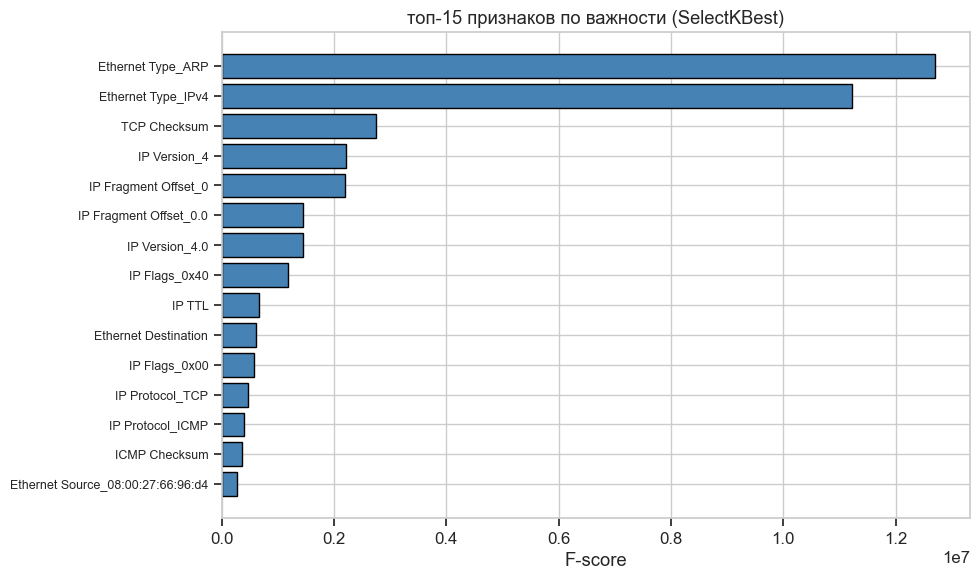


отобрано признаков: 55 из 102
сокращение: 46.1%
признаков: 102 → 55

топ-10 признаков:
['TCP Destination Port', 'UDP Checksum', 'IP Fragment Offset_0.0', 'IP Fragment Offset_0', 'UDP Source Port', 'IP Length', 'HTTP Full URI', 'TCP Checksum', 'Ethernet Source_08:00:27:5d:ef:d9', 'IP Flags_0x40']

сохранено: processed/X_selected_all_kbest.csv
график: processed/all_feature_importance_kbest.png


In [39]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
import matplotlib.pyplot as plt
import os

os.makedirs('processed', exist_ok=True)

# загружаем закодированные данные
X_encoded = pd.read_csv('processed/X_encoded.csv')
y = pd.read_csv('processed/y_target.csv') if os.path.exists('processed/y_target.сsv') else df_processed['attack_class']

# убеждаемся что нет пропусков
X_encoded = X_encoded.fillna(0)

print(f'всего признаков после кодирования: {X_encoded.shape[1]}')
print(f'записей: {X_encoded.shape[0]:,}')

# F-тест для многоклассовой классификации
selector_f = SelectKBest(score_func=f_classif, k=40)
selector_f.fit(X_encoded, y)
selected_f = X_encoded.columns[selector_f.get_support()].tolist()

# Mutual Information для нелинейных зависимостей
selector_mi = SelectKBest(score_func=mutual_info_classif, k=40)
selector_mi.fit(X_encoded, y)
selected_mi = X_encoded.columns[selector_mi.get_support()].tolist()

# объединяем результаты
selected_features_all = list(set(selected_f) | set(selected_mi))

# визуализация топ-15 признаков
fig, ax = plt.subplots(figsize=(10, 6))
scores_df = pd.DataFrame({
    'feature': X_encoded.columns,
    'f_score': selector_f.scores_,
    'mi_score': selector_mi.scores_
}).sort_values('f_score', ascending=False).head(15)

ax.barh(range(len(scores_df)), scores_df['f_score'], color='steelblue', edgecolor='black')
ax.set_yticks(range(len(scores_df)))
ax.set_yticklabels([f[:40] for f in scores_df['feature']], fontsize=9)
ax.set_xlabel('F-score')
ax.set_title('топ-15 признаков по важности (SelectKBest)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('processed/all_feature_importance_kbest.png', dpi=150, bbox_inches='tight')
plt.show()

# сохраняем отобранные признаки
X_selected_all = X_encoded[selected_features_all].copy()
X_selected_all.to_csv('processed/X_selected_all_kbest.csv', index=False)

print(f'\nотобрано признаков: {len(selected_features_all)} из {X_encoded.shape[1]}')
print(f'сокращение: {round((1 - len(selected_features_all)/X_encoded.shape[1])*100, 1)}%')
print(f'признаков: {X_encoded.shape[1]} → {len(selected_features_all)}')
print(f'\nтоп-10 признаков:\n{selected_features_all[:10]}')
print(f'\nсохранено: processed/X_selected_all_kbest.csv')
print(f'график: processed/all_feature_importance_kbest.png')

всего признаков: 102
записей: 4,543,916
удалено константных признаков: 32
сэмплирование: 200,000 строк


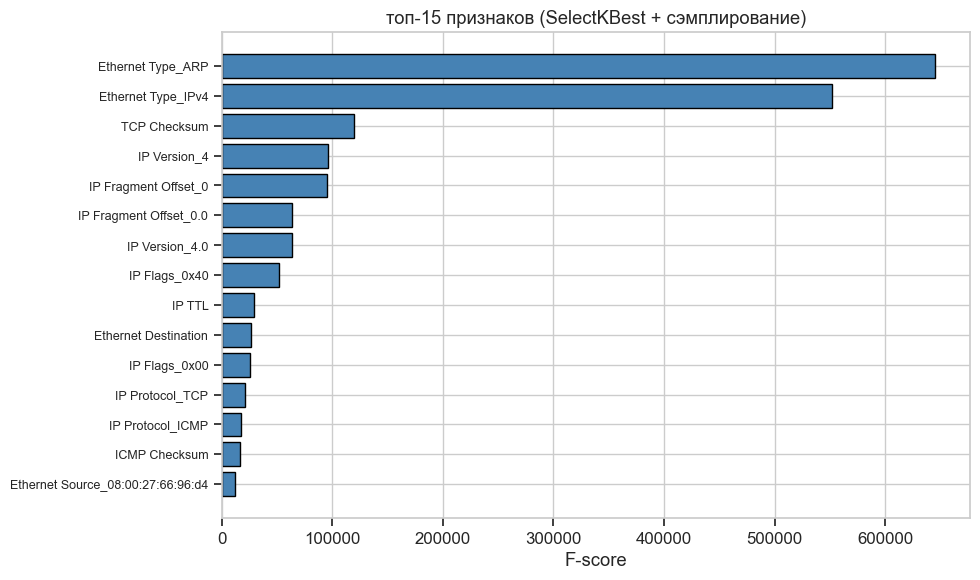

признаков: 102 → 40
сохранено: processed/X_selected_kbest_sample.csv


In [35]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold
import matplotlib.pyplot as plt
import os
import time

os.makedirs('processed', exist_ok=True)


# убеждаемся что нет пропусков
X_encoded = X_encoded.fillna(0)

print(f'всего признаков: {X_encoded.shape[1]}')
print(f'записей: {X_encoded.shape[0]:,}')

# 1) Удаляем константные и околоконстантные признаки
selector_var = VarianceThreshold(threshold=0.01)  # удаляет признаки с дисперсией < 0.01
X_encoded_var = pd.DataFrame(
    selector_var.fit_transform(X_encoded),
    columns=X_encoded.columns[selector_var.get_support()]
)
print(f'удалено константных признаков: {X_encoded.shape[1] - X_encoded_var.shape[1]}')

# 2) Сэмплирование для быстрого отбора (200K вместо 4.5M)
sample_size = min(200_000, len(X_encoded_var))
if len(X_encoded_var) > sample_size:
    idx = np.random.choice(len(X_encoded_var), sample_size, replace=False)
    X_sample = X_encoded_var.iloc[idx]
    y_sample = y.iloc[idx]
    print(f'сэмплирование: {sample_size:,} строк')
else:
    X_sample = X_encoded_var
    y_sample = y

# 3) SelectKBest только с f_classif (быстро и достаточно)
selector = SelectKBest(score_func=f_classif, k=40)
selector.fit(X_sample, y_sample)
selected_features = X_encoded_var.columns[selector.get_support()].tolist()


# 4) Применяем отбор ко всему датасету
X_selected = X_encoded[selected_features].copy()
X_selected.to_csv('processed/X_selected_kbest_sample.csv', index=False)

# 5) Визуализация
fig, ax = plt.subplots(figsize=(10, 6))
scores_df = pd.DataFrame({
    'feature': X_encoded_var.columns,
    'f_score': selector.scores_
}).sort_values('f_score', ascending=False).head(15)

ax.barh(range(len(scores_df)), scores_df['f_score'], color='steelblue', edgecolor='black')
ax.set_yticks(range(len(scores_df)))
ax.set_yticklabels([f[:40] for f in scores_df['feature']], fontsize=9)
ax.set_xlabel('F-score')
ax.set_title('топ-15 признаков (SelectKBest + сэмплирование)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('processed/feature_importance_kbest_sample.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'признаков: {X_encoded.shape[1]} → {len(selected_features)}')
print(f'сохранено: processed/X_selected_kbest_sample.csv')

Разделение на выборки

In [36]:
from sklearn.model_selection import train_test_split

# Сначала разделяем на train (70%) и временный набор (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_selected, y, 
    test_size=0.3, 
    random_state=42,  # для воспроизводимости
    stratify=y  # сохраняем пропорции классов
)

# Затем делим временный набор на validation (15%) и test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, 
    test_size=0.5,  # 50% от 30% = 15% от общего
    random_state=42,
    stratify=y_temp
)

print(f"Train set:     {X_train.shape[0]:,} записей ({X_train.shape[0]/len(X_selected)*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]:,} записей ({X_val.shape[0]/len(X_selected)*100:.1f}%)")
print(f"Test set:      {X_test.shape[0]:,} записей ({X_test.shape[0]/len(X_selected)*100:.1f}%)")

print("Train:")
print(y_train.value_counts(normalize=True).sort_index().round(3))
print("\nValidation:")
print(y_val.value_counts(normalize=True).sort_index().round(3))
print("\nTest:")
print(y_test.value_counts(normalize=True).sort_index().round(3))

os.makedirs('processed/splits', exist_ok=True)

X_train.to_csv('processed/splits/X_train.csv', index=False)
X_val.to_csv('processed/splits/X_val.csv', index=False)
X_test.to_csv('processed/splits/X_test.csv', index=False)

y_train.to_csv('processed/splits/y_train.csv', index=False)
y_val.to_csv('processed/splits/y_val.csv', index=False)
y_test.to_csv('processed/splits/y_test.csv', index=False)


Train set:     3,180,741 записей (70.0%)
Validation set: 681,587 записей (15.0%)
Test set:      681,588 записей (15.0%)
Train:
attack_class
ARP-spoof          0.021
Benign             0.277
DDoS               0.186
DoS                0.081
FTP-Attack         0.046
FTP-Brute-Force    0.027
Fuzzing            0.026
ICMP-Flood         0.053
Port-Scanning      0.036
RCE                0.061
SQL-Injection      0.063
SSH-Brute-Force    0.031
SYN-Flood          0.044
XSS                0.048
Name: proportion, dtype: float64

Validation:
attack_class
ARP-spoof          0.021
Benign             0.277
DDoS               0.186
DoS                0.081
FTP-Attack         0.046
FTP-Brute-Force    0.027
Fuzzing            0.026
ICMP-Flood         0.053
Port-Scanning      0.036
RCE                0.061
SQL-Injection      0.063
SSH-Brute-Force    0.031
SYN-Flood          0.044
XSS                0.048
Name: proportion, dtype: float64

Test:
attack_class
ARP-spoof          0.021
Benign             0.27

самый частый класс встречается в 13 раз чаще, чем самый редкий. Это умеренный дисбаланс — не критично, но требует внимания.

In [ ]:
# 1. Проверка на пустые классы
expected_classes = set(y.value_counts().index)
actual_classes = set(y_train.unique())
if len(actual_classes) < len(expected_classes):
    print(f' Некоторые классы отсутствуют в train: {expected_classes - actual_classes}')

# 2. Проверка дисбаланса
train_counts = y_train.value_counts()
imbalance_ratio = train_counts.iloc[0] / train_counts.iloc[-1]
print(f'Дисбаланс в train: {imbalance_ratio:.1f}:1')


📊 Дисбаланс в train: 13.0:1


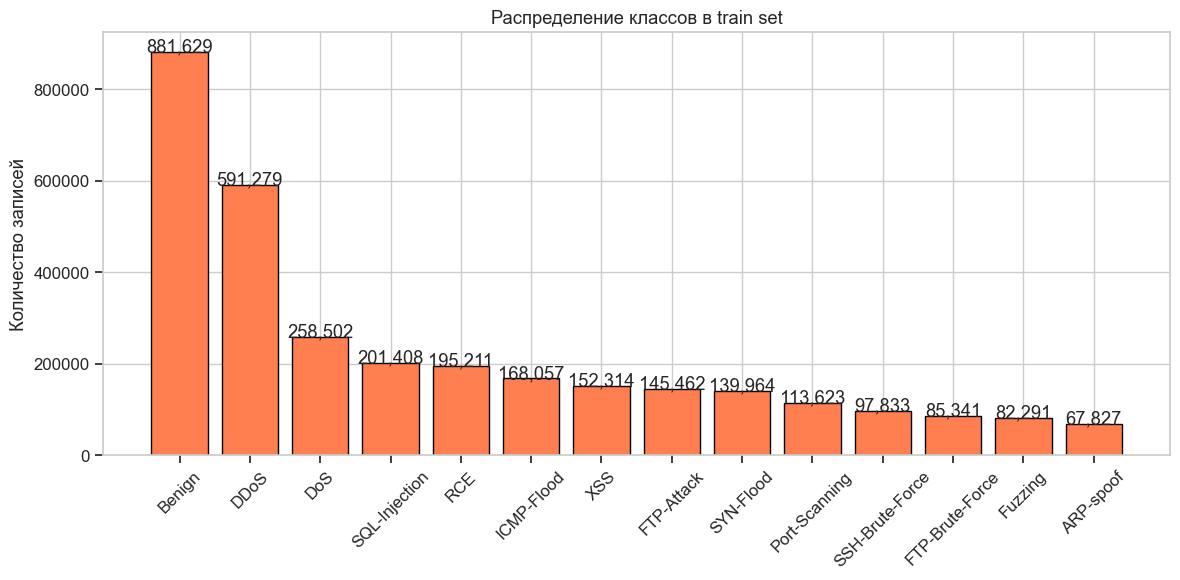

 Сохранён график: processed/splits/class_distribution_train.png


In [38]:
# Быстрая визуализация распределения классов в train
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
train_counts = y_train.value_counts()
bars = plt.bar(range(len(train_counts)), train_counts.values, color='coral', edgecolor='black')
plt.xticks(range(len(train_counts)), [c[:15] + '...' if len(c) > 15 else c for c in train_counts.index], rotation=45)
plt.ylabel('Количество записей')
plt.title('Распределение классов в train set')
for bar, val in zip(bars, train_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{val:,}', ha='center')
plt.tight_layout()
plt.savefig('processed/splits/class_distribution_train.png', dpi=150, bbox_inches='tight')
plt.show()

print(f' Сохранён график: processed/splits/class_distribution_train.png')

In [41]:
from sklearn.model_selection import train_test_split

# Сначала разделяем на train (70%) и временный набор (30%)
X_train_all, X_temp_all, y_train_all, y_temp_all = train_test_split(
    X_selected_all, y, 
    test_size=0.3, 
    random_state=42,  # для воспроизводимости
    stratify=y  # сохраняем пропорции классов
)

# Затем делим временный набор на validation (15%) и test (15%)
X_val_all, X_test_all, y_val_all, y_test_all = train_test_split(
    X_temp_all, y_temp_all, 
    test_size=0.5,  # 50% от 30% = 15% от общего
    random_state=42,
    stratify=y_temp
)

print(f"Train set:     {X_train_all.shape[0]:,} записей ({X_train_all.shape[0]/len(X_selected_all)*100:.1f}%)")
print(f"Validation set: {X_val_all.shape[0]:,} записей ({X_val_all.shape[0]/len(X_selected_all)*100:.1f}%)")
print(f"Test set:      {X_test_all.shape[0]:,} записей ({X_test_all.shape[0]/len(X_selected_all)*100:.1f}%)")

print("Train:")
print(y_train_all.value_counts(normalize=True).sort_index().round(3))
print("\nValidation:")
print(y_val_all.value_counts(normalize=True).sort_index().round(3))
print("\nTest:")
print(y_test_all.value_counts(normalize=True).sort_index().round(3))

os.makedirs('processed/splits', exist_ok=True)

X_train_all.to_csv('processed/splits/X_train_all.csv', index=False)
X_val_all.to_csv('processed/splits/X_val_all.csv', index=False)
X_test_all.to_csv('processed/splits/X_test_all.csv', index=False)

y_train_all.to_csv('processed/splits/y_train_all.csv', index=False)
y_val_all.to_csv('processed/splits/y_val_all.csv', index=False)
y_test_all.to_csv('processed/splits/y_test_all.csv', index=False)


Train set:     3,180,741 записей (70.0%)
Validation set: 681,587 записей (15.0%)
Test set:      681,588 записей (15.0%)
Train:
attack_class
ARP-spoof          0.021
Benign             0.277
DDoS               0.186
DoS                0.081
FTP-Attack         0.046
FTP-Brute-Force    0.027
Fuzzing            0.026
ICMP-Flood         0.053
Port-Scanning      0.036
RCE                0.061
SQL-Injection      0.063
SSH-Brute-Force    0.031
SYN-Flood          0.044
XSS                0.048
Name: proportion, dtype: float64

Validation:
attack_class
ARP-spoof          0.021
Benign             0.277
DDoS               0.186
DoS                0.081
FTP-Attack         0.046
FTP-Brute-Force    0.027
Fuzzing            0.026
ICMP-Flood         0.053
Port-Scanning      0.036
RCE                0.061
SQL-Injection      0.063
SSH-Brute-Force    0.031
SYN-Flood          0.044
XSS                0.048
Name: proportion, dtype: float64

Test:
attack_class
ARP-spoof          0.021
Benign             0.27

- Шаг 11
Обучение  моделей
LightGBM, RandomForest, XGBoost, Isolation Forest
- Шаг 12
Сравнение моделей и выбор лучшей
Оценка по метрикам (F1, ROC-AUC, Accuracy)

In [ ]:
!pip install feature_engine boruta mlxtend

Автоматический отбор признаков

In [ ]:
from sklearn.feature_selection import (
    SelectKBest, f_classif,        # статистический тест
    RFE, RFECV,                    # рекурсивное исключение
    SelectFromModel                # отбор через модель
)
